# K-W test across radiomics features

In [1]:
import os
import glob
from collections import defaultdict
import pandas as pd


def merged_csv(dir_path):
    all_csvs = glob.glob(os.path.join(dir_path, "*", "*spine_vertebrae*.csv"))
    csv_dict = defaultdict(list)
    result_dict = {}
    for file in all_csvs:
        csv_name = os.path.basename(file)
        csv_dict[csv_name].append(file)

    for csv_name, files in csv_dict.items():
        dfs = []
        for file in files:
            df = pd.read_csv(file)
            patient_name = os.path.basename(os.path.dirname(file))
            df.insert(0, "patient", patient_name)
            dfs.append(df)

        key_name = csv_name.replace("_radiomics_spine_vertebrae_features.csv", "")
        big_df = pd.concat(dfs, ignore_index=True)
        result_dict[key_name] = big_df
    return result_dict

In [23]:
from scipy.stats import kruskal
import numpy as np

clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
categoric_features_clinical = ["ISS classification", "M-protein type", "Light chain type"]

all_csvs = merged_csv(r"E:\DATA_Myelomy")
for name, radiomic_df in all_csvs.items():
    print(f"Processing: {name}")

    merged_df = pd.merge(radiomic_df, clinical_df, left_on='patient', right_on='Patient ID')
    numeric_features_image = radiomic_df.select_dtypes(include=['number']).columns

    kruskal_wallis = {}
    for radiomic_col in numeric_features_image:
        data_subset = merged_df[[radiomic_col, "ISS classification"]].dropna()
        groups = [
            group[radiomic_col].values
            for _, group in data_subset.groupby("ISS classification")
        ]

        groups = [g for g in groups if len(g) > 1]

        if len(groups) < 2:
            continue

        all_values = np.concatenate(groups)
        if np.all(all_values == all_values[0]):
            continue

        try:
            stat, p_value = kruskal(*groups)
            kruskal_wallis[radiomic_col] = {'stat': stat, 'p_value': p_value}
        except ValueError:
            continue

    kruskal_wallis_df = pd.DataFrame(kruskal_wallis).T
    kruskal_wallis_df = kruskal_wallis_df.sort_values(by='stat', ascending=False)
    print(f"Significant features: {(kruskal_wallis_df['p_value'] < 0.05).sum()}")
    print(kruskal_wallis_df.head(10))
    print("-" * 50)

Processing: BMD
Significant features: 19
                                                         stat   p_value
original_firstorder_Energy                          11.794678  0.002747
original_firstorder_TotalEnergy                     11.169427  0.003755
gradient_ngtdm_Coarseness                            9.570853  0.008351
original_shape_VoxelVolume                           9.261451  0.009748
gradient_glrlm_RunLengthNonUniformity                9.175249  0.010177
original_shape_MeshVolume                            9.116191  0.010482
original_glrlm_RunLengthNonUniformity                8.514791  0.014159
original_gldm_LargeDependenceHighGrayLevelEmphasis   8.165730  0.016859
gradient_gldm_DependenceNonUniformity                8.016547  0.018165
original_shape_SurfaceVolumeRatio                    7.315546  0.025790
--------------------------------------------------
Processing: CaSupp_25
Significant features: 36
                                            stat   p_value
original_f

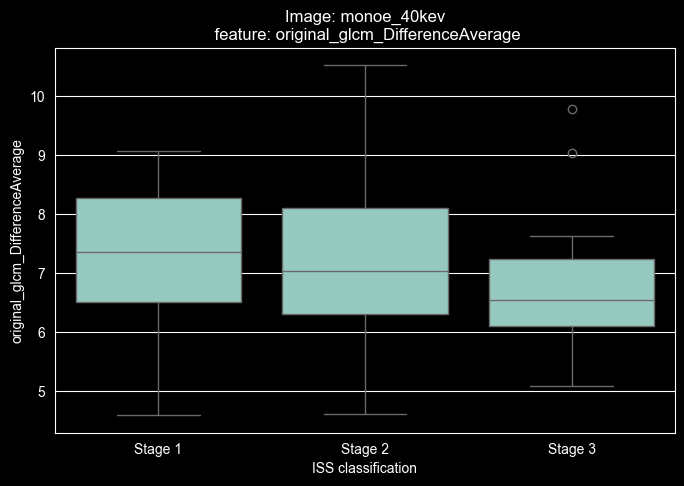

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

image = "monoe_40kev"
feature = "original_glcm_DifferenceAverage"

merged_df = pd.merge(all_csvs[image], clinical_df, left_on='patient', right_on='Patient ID')
plt.figure(figsize=(8, 5))
sns.boxplot(data=merged_df, x="ISS classification", y=feature)
plt.title(f"Image: {image}\n feature: {feature}")
plt.show()

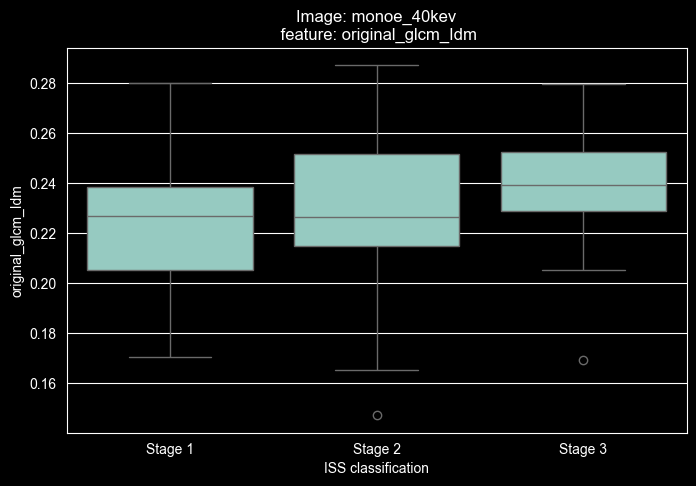

In [25]:
image = "monoe_40kev"
feature = "original_glcm_Idm"

merged_df = pd.merge(all_csvs[image], clinical_df, left_on='patient', right_on='Patient ID')
plt.figure(figsize=(8, 5))
sns.boxplot(data=merged_df, x="ISS classification", y=feature)
plt.title(f"Image: {image}\n feature: {feature}")
plt.show()

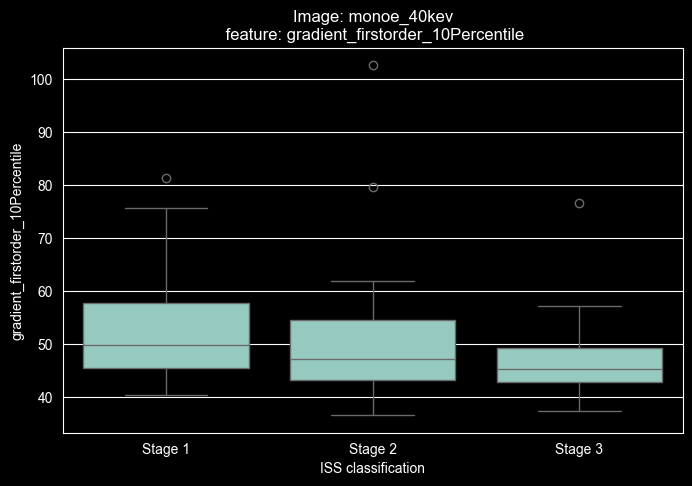

In [26]:
image = "monoe_40kev"
feature = "gradient_firstorder_10Percentile"

merged_df = pd.merge(all_csvs[image], clinical_df, left_on='patient', right_on='Patient ID')
plt.figure(figsize=(8, 5))
sns.boxplot(data=merged_df, x="ISS classification", y=feature)
plt.title(f"Image: {image}\n feature: {feature}")
plt.show()

# HEALTHY FOLLOW-UP

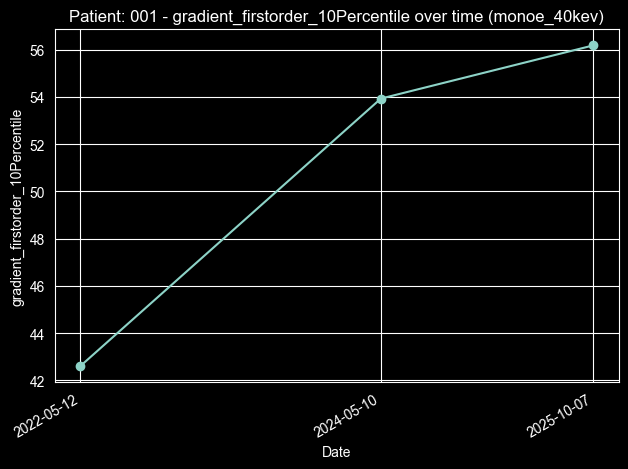

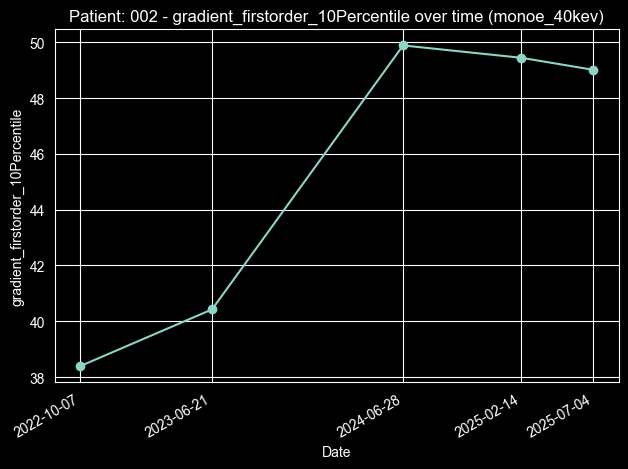

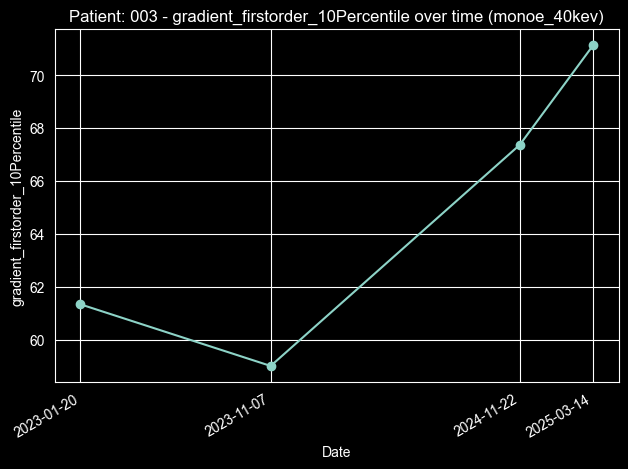

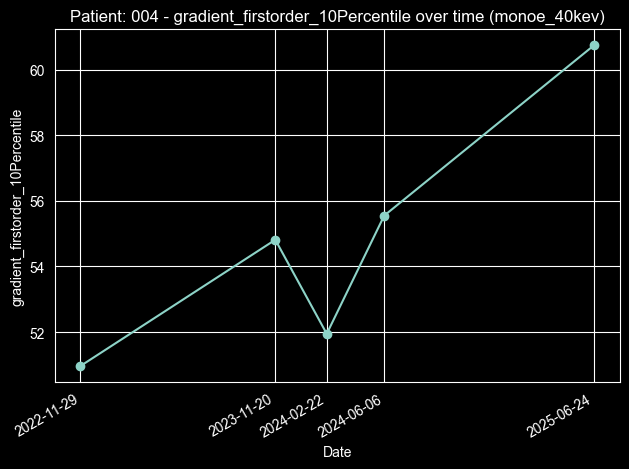

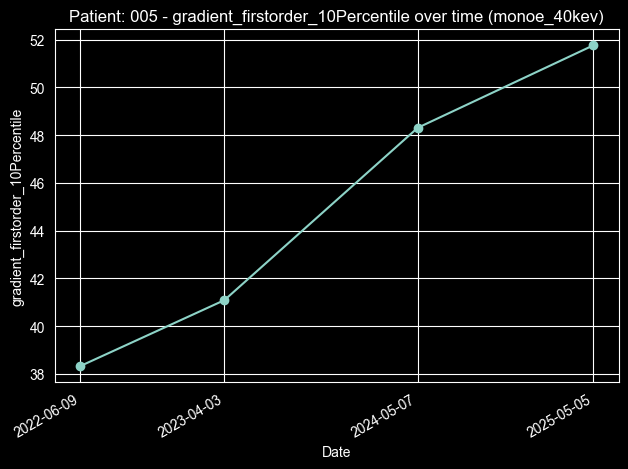

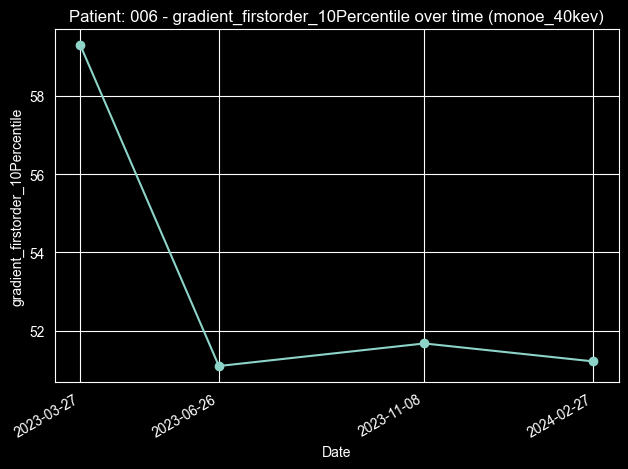

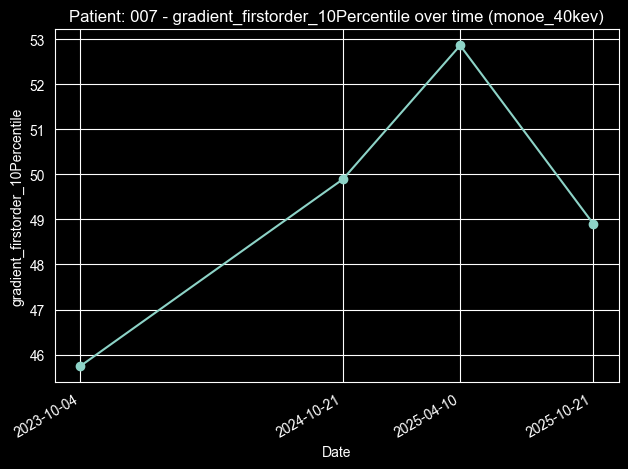

In [2]:
import os
import re
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt


main_folder_path = r"E:\DATA_FollowUp"

image_types = ["CaSupp_25", "konv", "monoe_40kev"]
patients = {img: defaultdict(list) for img in image_types}

pattern = r"Myel_FollowUp_(\d+)_(\d+)"

for folder in os.listdir(main_folder_path):
    match = re.match(pattern, folder)
    if match:
        patient_id = match.group(1)
        followup_number = int(match.group(2))

        folder_path = os.path.join(main_folder_path, folder)
        for file in os.listdir(folder_path):
            if file.endswith(".csv") and "spine_vertebrae" in file:
                for img in image_types:
                    if img in file:
                        csv_path = os.path.join(folder_path, file)
                        patients[img][patient_id].append((followup_number, csv_path))

patient_dates = {
    "001": ["12-05-2022", "10-05-2024", "07-10-2025"],
    "002": ["07-10-2022", "21-06-2023", "28-06-2024", "14-02-2025", "04-07-2025"],
    "003": ["20-01-2023", "07-11-2023", "22-11-2024", "14-03-2025"],
    "004": ["29-11-2022", "20-11-2023", "22-02-2024", "06-06-2024", "24-06-2025"],
    "005": ["09-06-2022", "03-04-2023", "07-05-2024", "05-05-2025"],
    "006": ["27-03-2023", "26-06-2023", "08-11-2023", "27-02-2024"],
    "007": ["04-10-2023", "21-10-2024", "10-04-2025", "21-10-2025"],
    # "008": [],
}

patient_follow_up_dfs = {}

for img_type, patient_data in patients.items():
    patient_follow_up_dfs[img_type] = {}

    for patient, scans in patient_data.items():
        scans = sorted(scans, key=lambda x: x[0])
        dfs = []
        for followup, path in scans:
            df = pd.read_csv(path)
            dfs.append(df)

        patient_df = pd.concat(dfs, ignore_index=True)
        patient_df.insert(0, "Date", patient_dates[patient])
        patient_follow_up_dfs[img_type][patient] = patient_df

image_type = "monoe_40kev"
feature = "gradient_firstorder_10Percentile"

for patient, df in patient_follow_up_dfs[image_type].items():
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
    df = df.sort_values("Date")
    plt.plot(df["Date"], df[feature], marker="o")
    plt.xlabel("Date")
    plt.ylabel(feature)
    plt.title(f"Patient: {patient} - {feature} over time ({image_type})")
    plt.xticks(df["Date"], df["Date"].dt.strftime("%Y-%m-%d"))
    plt.grid(True)
    plt.gcf().autofmt_xdate()

    plt.tight_layout()
    plt.show()

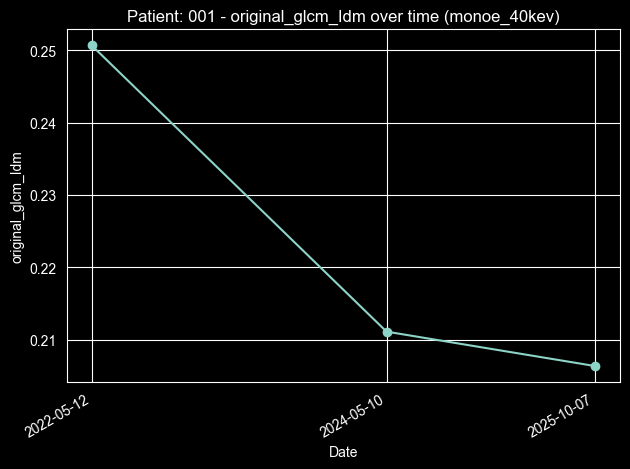

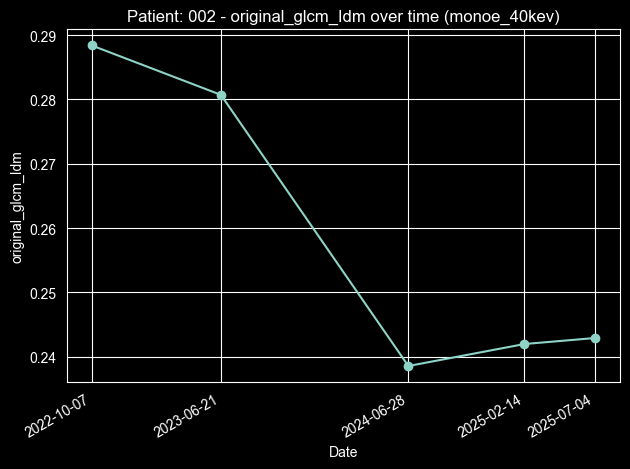

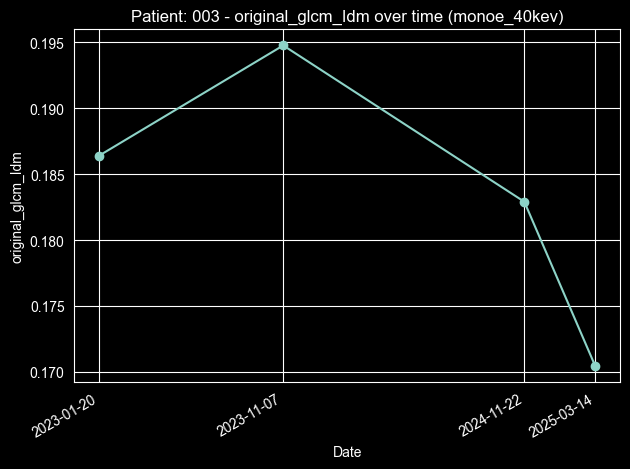

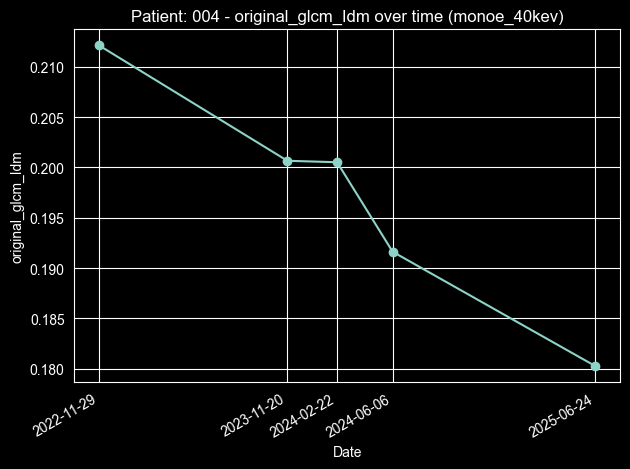

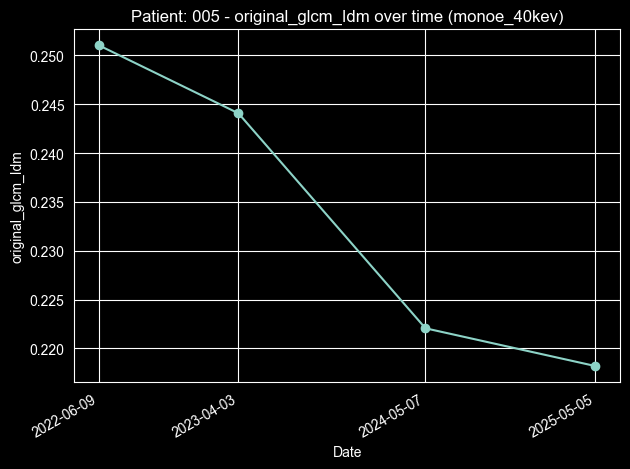

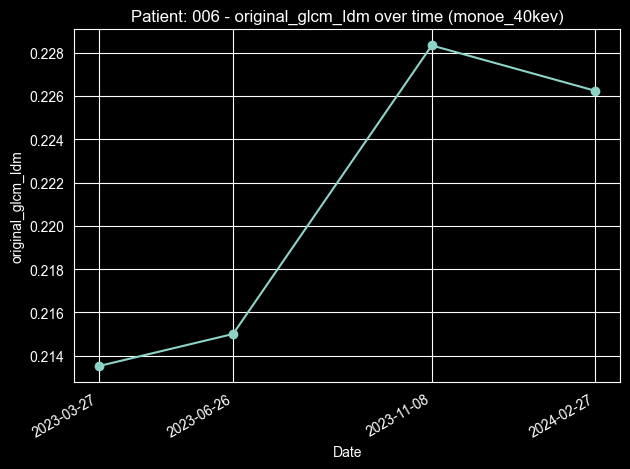

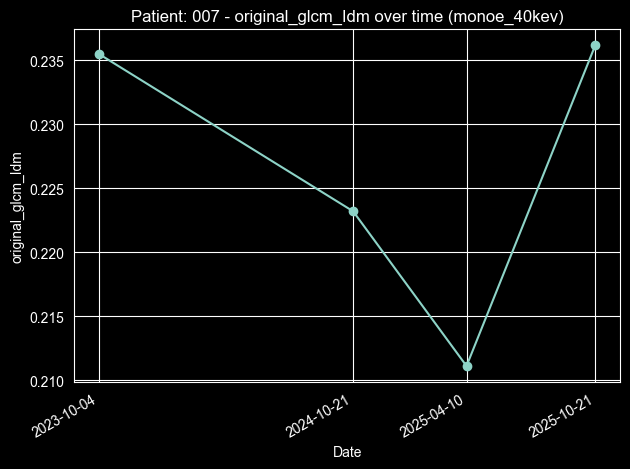

In [3]:
image_type = "monoe_40kev"
feature = "original_glcm_Idm"

for patient, df in patient_follow_up_dfs[image_type].items():
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
    df = df.sort_values("Date")
    plt.plot(df["Date"], df[feature], marker="o")
    plt.xlabel("Date")
    plt.ylabel(feature)
    plt.title(f"Patient: {patient} - {feature} over time ({image_type})")
    plt.xticks(df["Date"], df["Date"].dt.strftime("%Y-%m-%d"))
    plt.grid(True)
    plt.gcf().autofmt_xdate()

    plt.tight_layout()
    plt.show()

Zobraziť zdrave vs leze v jednom grafe

Všetkých pacientov do jedného grafu

štandardizace leze a zdrave a vykresliť ("-" || "/")